# PatchTST grid search — W&B analysis

This notebook pulls finished runs from two Weights & Biases projects that mirror the hyperparameter grid in `scripts/sweep_job.sh`:

- **PatchTST_Depth_Width_Search** — grid over patch/stride, depth, heads, dropout, weight decay, augmentations, etc. (see `scripts/sweep_job.sh`). In your setup this arm uses a **Linear** classification head (verify `classifier` in W&B config).
- **PatchTST_MLP_Classifier** — same search space with an **MLP** head instead of Linear.

**Questions addressed**

1. How do **patch length** and **stride** affect **macro F1** (`f1_score` in W&B, logged each epoch)?
2. **Linear vs MLP** head — which is better on average and at the top end?
3. **Regularization** — trends for `t_dropout`, `weight_decay`, depth (`t_num_layers`), and heads (`t_heads`).
4. **Data augmentation** — whether `jitter_prob`, `shift_prob`, `twarp_prob`, and `mwarp_prob` materially affect macro F1 (compare to the paper’s finding that augmentation had little impact).

**Outputs**

- Figures: heatmaps, distributions, and scatter/correlation views.
- **Top 10** runs by best macro F1 → YAML files under `configs/` (`grid_top_1.yaml` … `grid_top_10.yaml`), merged with `configs/config_1.yaml` as a base.

**Setup**: `pip install wandb pandas matplotlib seaborn pyyaml` and `wandb login` (or set `WANDB_API_KEY`). Adjust `WANDB_ENTITY` in the next cell if your entity name differs.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Any, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
import yaml

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001

# Repo root (parent of visualizations/)
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "visualizations":
    REPO_ROOT = REPO_ROOT.parent

BASE_CONFIG_PATH = REPO_ROOT / "configs" / "config_1.yaml"
CONFIG_EXPORT_DIR = REPO_ROOT / "configs"

WANDB_ENTITY = "nikhitrivedi1-northeastern-university"
WANDB_PROJECTS = [
    "PatchTST_Depth_Width_Search",
    "PatchTST_MLP_Classifier",
]

# Finished runs only; set to {"state": "finished", "config.run_type": "validation"} if you need to exclude test runs
RUN_FILTERS = {"state": "finished"}

# Use per-epoch history for best F1 (recommended). Set False to use W&B summary only (last logged epoch — faster, can mis-rank if F1 peaked earlier)
USE_BEST_F1_FROM_HISTORY = True

In [2]:
import pandas as pd
import wandb


def best_f1_macro(run: Any) -> Optional[float]:
    """Best macro F1 across logged epochs (same metric as train.py: MulticlassF1Score average='macro')."""
    if not USE_BEST_F1_FROM_HISTORY:
        v = run.summary.get("f1_score")
        return float(v) if v is not None else None
    best = None
    try:
        for row in run.scan_history(keys=["f1_score"]):
            v = row.get("f1_score")
            if v is None:
                continue
            v = float(v)
            best = v if best is None else max(best, v)
    except Exception:
        best = None
    if best is None:
        v = run.summary.get("f1_score")
        best = float(v) if v is not None else None
    return best


def fetch_grid_runs(
    projects: list[str],
    entity: str = WANDB_ENTITY,
    filters: dict | None = None,
    require_valid_patch_stride: bool = True,
) -> pd.DataFrame:
    """
    Load sweep runs aligned with scripts/sweep_job.sh knobs.
    Config keys follow train.py / YAML (t_dropout, t_heads, etc.).
    """
    if filters is None:
        filters = RUN_FILTERS
    api = wandb.Api()
    records: list[dict] = []

    for project in projects:
        runs = api.runs(f"{entity}/{project}", filters=filters)
        for r in runs:
            cfg = r.config or {}
            stride = cfg.get("stride")
            patch_length = cfg.get("patch_length")
            if require_valid_patch_stride:
                if patch_length is None or stride is None or patch_length < stride:
                    continue

            f1 = best_f1_macro(r)
            # W&B may store heads as t_heads (train.py) — tolerate aliases
            n_heads = cfg.get("t_heads") or cfg.get("n_heads") or cfg.get("t_num_heads")

            records.append(
                {
                    "run_id": r.id,
                    "name": r.name,
                    "project": project,
                    "state": r.state,
                    "run_type": cfg.get("run_type"),
                    "patch_length": patch_length,
                    "stride": stride,
                    "lr": cfg.get("lr"),
                    "t_dropout": cfg.get("t_dropout"),
                    "t_num_layers": cfg.get("t_num_layers"),
                    "t_heads": n_heads,
                    "optimizer": cfg.get("optimizer"),
                    "weight_decay": cfg.get("weight_decay"),
                    "classifier": cfg.get("classifier"),
                    "jitter_prob": cfg.get("jitter_prob"),
                    "shift_prob": cfg.get("shift_prob"),
                    "twarp_prob": cfg.get("twarp_prob"),
                    "mwarp_prob": cfg.get("mwarp_prob"),
                    "lookback_window": cfg.get("lookback_window"),
                    "positional_encoding": cfg.get("positional_encoding"),
                    "f1_macro": f1,
                    "train_loss_last": r.summary.get("train/epoch_loss"),
                    "eval_loss_last": r.summary.get("valid/epoch_loss") or r.summary.get("test/epoch_loss"),
                }
            )

    df = pd.DataFrame(records)
    if df.empty:
        return df
    df["patch_stride"] = df["patch_length"].astype(str) + " / " + df["stride"].astype(str)
    df["project_short"] = df["project"].map(
        {
            "PatchTST_Depth_Width_Search": "Depth_Width_Search",
            "PatchTST_MLP_Classifier": "MLP_Classifier",
        }
    ).fillna(df["project"])
    return df


def merge_config_with_base(run_row: pd.Series, base_path: Path) -> dict:
    """Overlay a single run's hyperparameters onto the repo base YAML."""
    with open(base_path) as f:
        cfg = yaml.safe_load(f)
    keys = [
        "patch_length",
        "stride",
        "lr",
        "weight_decay",
        "optimizer",
        "t_dropout",
        "t_num_layers",
        "t_heads",
        "classifier",
        "jitter_prob",
        "shift_prob",
        "twarp_prob",
        "mwarp_prob",
        "positional_encoding",
        "lookback_window",
        "run_type",
    ]
    for k in keys:
        v = run_row.get(k)
        if v is not None and not pd.isna(v):
            cfg[k] = v
    return cfg

In [3]:
df = fetch_grid_runs(WANDB_PROJECTS)
print(f"Loaded {len(df)} runs from {WANDB_PROJECTS}")
if len(df):
    print("f1_macro: min/median/max", df["f1_macro"].min(), df["f1_macro"].median(), df["f1_macro"].max())
    display(df.head(10))
else:
    print("No runs — check WANDB_ENTITY, project names, and wandb login.")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/nikhiltrivedi/.netrc.


Loaded 1668 runs from ['PatchTST_Depth_Width_Search', 'PatchTST_MLP_Classifier']
f1_macro: min/median/max 0.05241164565086365 0.46768438816070557 0.5674121379852295


,run_id,name,project,state,run_type,patch_length,stride,lr,t_dropout,t_num_layers,...,shift_prob,twarp_prob,mwarp_prob,lookback_window,positional_encoding,f1_macro,train_loss_last,eval_loss_last,patch_stride,project_short
0,kzalsust,pl32_s8_lr0.001_do0.2_L3_optadamw_h4_wd0p03_cl...,PatchTST_Depth_Width_Search,finished,validation,32,8,0.001,0.2,3,...,0,0,0.0,1024,None,0.551273,0.699215,0.736261,32 / 8,Depth_Width_Search
1,yd2d1t97,pl32_s8_lr0.001_do0.2_L3_optadamw_h4_wd0p01_cl...,PatchTST_Depth_Width_Search,finished,validation,32,8,0.001,0.2,3,...,0,0,0.0,1024,None,0.490105,0.751653,0.754852,32 / 8,Depth_Width_Search
2,2xc4kcai,pl32_s8_lr0.001_do0.2_L3_optadamw_h4_wd0p05_cl...,PatchTST_Depth_Width_Search,finished,validation,32,8,0.001,0.2,3,...,0,0,0.0,1024,None,0.529335,0.739256,0.763401,32 / 8,Depth_Width_Search
3,9scclibh,pl32_s8_lr0.001_do0.2_L3_optadamw_h8_wd0p01_cl...,PatchTST_Depth_Width_Search,finished,validation,32,8,0.001,0.2,3,...,0,0,0.0,1024,None,0.527382,0.701747,0.744378,32 / 8,Depth_Width_Search
4,9yfhmvbf,pl32_s8_lr0.001_do0.2_L3_optadamw_h8_wd0p03_cl...,PatchTST_Depth_Width_Search,finished,validation,32,8,0.001,0.2,3,...,0,0,0.0,1024,None,0.507565,0.721287,0.757574,32 / 8,Depth_Width_Search
5,7spf0guw,pl32_s8_lr0.001_do0.2_L3_optadamw_h16_wd0p01_c...,PatchTST_Depth_Width_Search,finished,validation,32,8,0.001,0.2,3,...,0,0,0.0,1024,None,0.531449,0.686893,0.754661,32 / 8,Depth_Width_Search
6,kcr9k0wu,pl32_s8_lr0.001_do0.2_L3_optadamw_h8_wd0p05_cl...,PatchTST_Depth_Width_Search,finished,validation,32,8,0.001,0.2,3,...,0,0,0.0,1024,None,0.514454,0.740019,0.747402,32 / 8,Depth_Width_Search
7,7008tbng,pl32_s8_lr0.001_do0.2_L3_optadamw_h16_wd0p03_c...,PatchTST_Depth_Width_Search,finished,validation,32,8,0.001,0.2,3,...,0,0,0.0,1024,None,0.526760,0.698030,0.764096,32 / 8,Depth_Width_Search
8,mbux2j71,pl32_s8_lr0.001_do0.2_L3_optadamw_h16_wd0p05_c...,PatchTST_Depth_Width_Search,finished,validation,32,8,0.001,0.2,3,...,0,0,0.0,1024,None,0.537632,0.721565,0.751068,32 / 8,Depth_Width_Search
9,j6hkag86,pl32_s8_lr0.001_do0.2_L5_optadamw_h4_wd0p01_cl...,PatchTST_Depth_Width_Search,finished,validation,32,8,0.001,0.2,5,...,0,0,0.0,1024,None,0.536214,0.687048,0.750499,32 / 8,Depth_Width_Search


## 1. Patch length & stride vs macro F1

Patching controls token count and overlap: smaller stride → more patches and more compute; patch size sets each token’s receptive field in samples. Use the heatmap for **mean** F1 over all other hyperparameters; the **line plots** show marginal **mean ± std** vs `patch_length` and vs `stride` separately; the box plot shows **spread** by `(patch, stride)` and project.

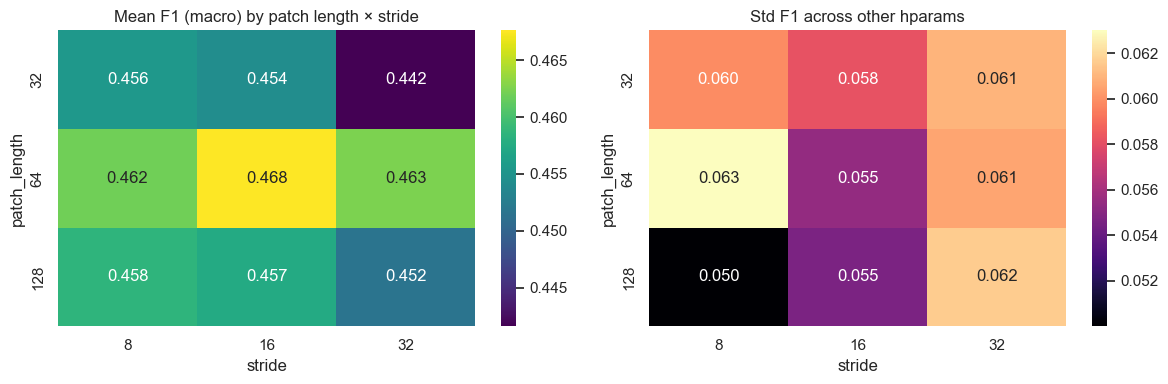

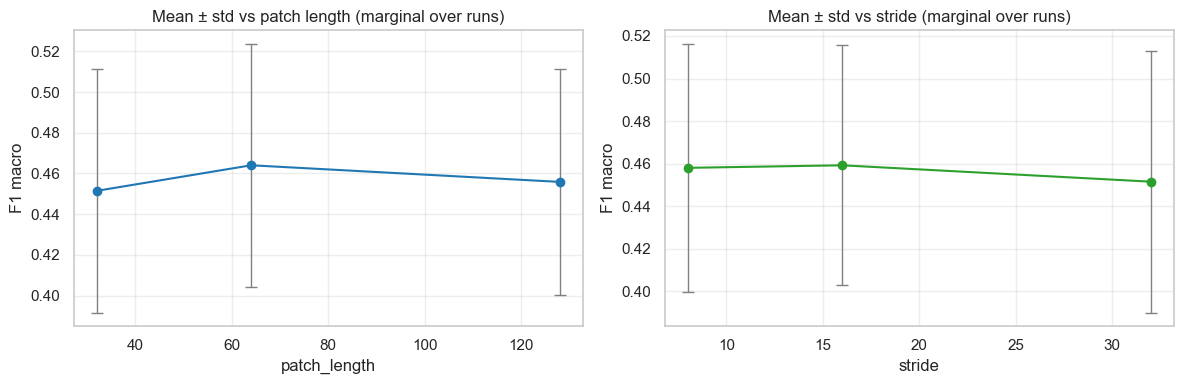

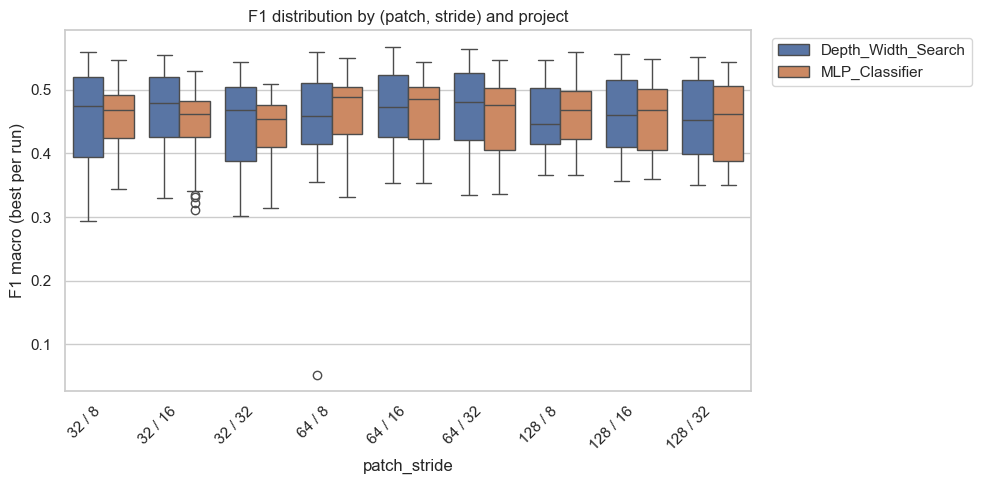

Highest mean F1 cell (patch_length, stride) = (np.int64(64), np.int64(16)), mean F1 = 0.4676


In [9]:
if len(df) == 0:
    print("Skip plots: empty dataframe")
else:
    sub = df.dropna(subset=["f1_macro", "patch_length", "stride"]).copy()
    pivot_mean = sub.pivot_table(
        index="patch_length", columns="stride", values="f1_macro", aggfunc="mean"
    )
    pivot_std = sub.pivot_table(
        index="patch_length", columns="stride", values="f1_macro", aggfunc="std"
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(pivot_mean, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
    axes[0].set_title("Mean F1 (macro) by patch length × stride")
    sns.heatmap(pivot_std, annot=True, fmt=".3f", cmap="magma", ax=axes[1])
    axes[1].set_title("Std F1 across other hparams")
    plt.tight_layout()
    plt.show()

    # Marginal trends: mean F1 ± std across all other hyperparameters (per patch_length or stride)
    agg_pl = (
        sub.groupby("patch_length", sort=True)["f1_macro"].agg(["mean", "std", "count"]).reset_index()
    )
    agg_st = sub.groupby("stride", sort=True)["f1_macro"].agg(["mean", "std", "count"]).reset_index()
    agg_pl["std"] = agg_pl["std"].fillna(0)
    agg_st["std"] = agg_st["std"].fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].errorbar(
        agg_pl["patch_length"],
        agg_pl["mean"],
        yerr=agg_pl["std"],
        fmt="-o",
        capsize=4,
        color="tab:blue",
        ecolor="gray",
        elinewidth=1,
    )
    axes[0].set_xlabel("patch_length")
    axes[0].set_ylabel("F1 macro")
    axes[0].set_title("Mean ± std vs patch length (marginal over runs)")
    axes[0].grid(True, alpha=0.35)

    axes[1].errorbar(
        agg_st["stride"],
        agg_st["mean"],
        yerr=agg_st["std"],
        fmt="-o",
        capsize=4,
        color="tab:green",
        ecolor="gray",
        elinewidth=1,
    )
    axes[1].set_xlabel("stride")
    axes[1].set_ylabel("F1 macro")
    axes[1].set_title("Mean ± std vs stride (marginal over runs)")
    axes[1].grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    order = sorted(sub["patch_stride"].unique(), key=lambda x: (int(x.split("/")[0]), int(x.split("/")[1])))
    sns.boxplot(data=sub, x="patch_stride", y="f1_macro", hue="project_short", order=order)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("F1 macro (best per run)")
    plt.title("F1 distribution by (patch, stride) and project")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    best_cell = pivot_mean.stack().idxmax()
    print(f"Highest mean F1 cell (patch_length, stride) = {best_cell}, mean F1 = {pivot_mean.loc[best_cell[0], best_cell[1]]:.4f}")

## 2. Linear vs MLP classifier

Use the **classifier** field when it differs within a project. If every run shows the same `classifier` (e.g. both sweeps used `mlp`), treat **project** as the factor of interest: **PatchTST_Depth_Width_Search** vs **PatchTST_MLP_Classifier** (the second column / violin plot).

/var/folders/j5/9qw1sp3j5yvdfl0r334_ctw80000gn/T/ipykernel_49253/3988439707.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha="right")


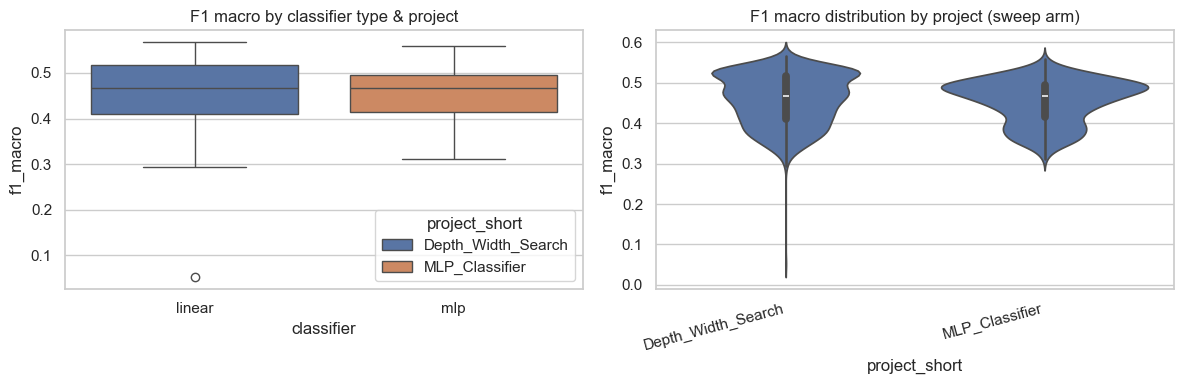

,,count,mean,median,max
project_short,classifier,,,,
Depth_Width_Search,linear,820,0.4585,0.4679,0.5674
MLP_Classifier,mlp,848,0.4544,0.4673,0.5591


Median F1 by project (arm):
 project_short
Depth_Width_Search    0.467928
MLP_Classifier        0.467317
Name: f1_macro, dtype: float64


In [5]:
if len(df) == 0:
    print("Skip plots: empty dataframe")
else:
    sub = df.dropna(subset=["f1_macro", "classifier"]).copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(data=sub, x="classifier", y="f1_macro", hue="project_short", ax=axes[0])
    axes[0].set_title("F1 macro by classifier type & project")
    sns.violinplot(data=sub, x="project_short", y="f1_macro", ax=axes[1], inner="box")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha="right")
    axes[1].set_title("F1 macro distribution by project (sweep arm)")
    plt.tight_layout()
    plt.show()

    summary = (
        sub.groupby(["project_short", "classifier"], dropna=False)["f1_macro"]
        .agg(["count", "mean", "median", "max"])
        .round(4)
    )
    display(summary)

    # Overall best single factor: compare project medians
    med_by_proj = sub.groupby("project_short")["f1_macro"].median().sort_values(ascending=False)
    print("Median F1 by project (arm):\n", med_by_proj)

## 3. Regularization & capacity trends

Explore **dropout**, **weight decay**, **depth**, and **heads** vs F1 using marginal **line plots** (mean ± std over runs at each discrete level), plus the correlation bar chart. These are correlational — interactions are visible in the multi-variate sweep. (Augmentation is analyzed separately in §4.)

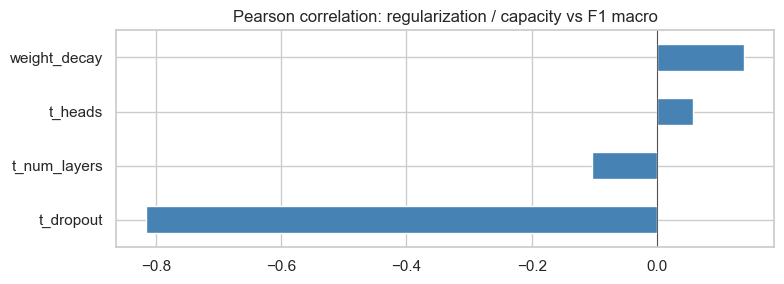

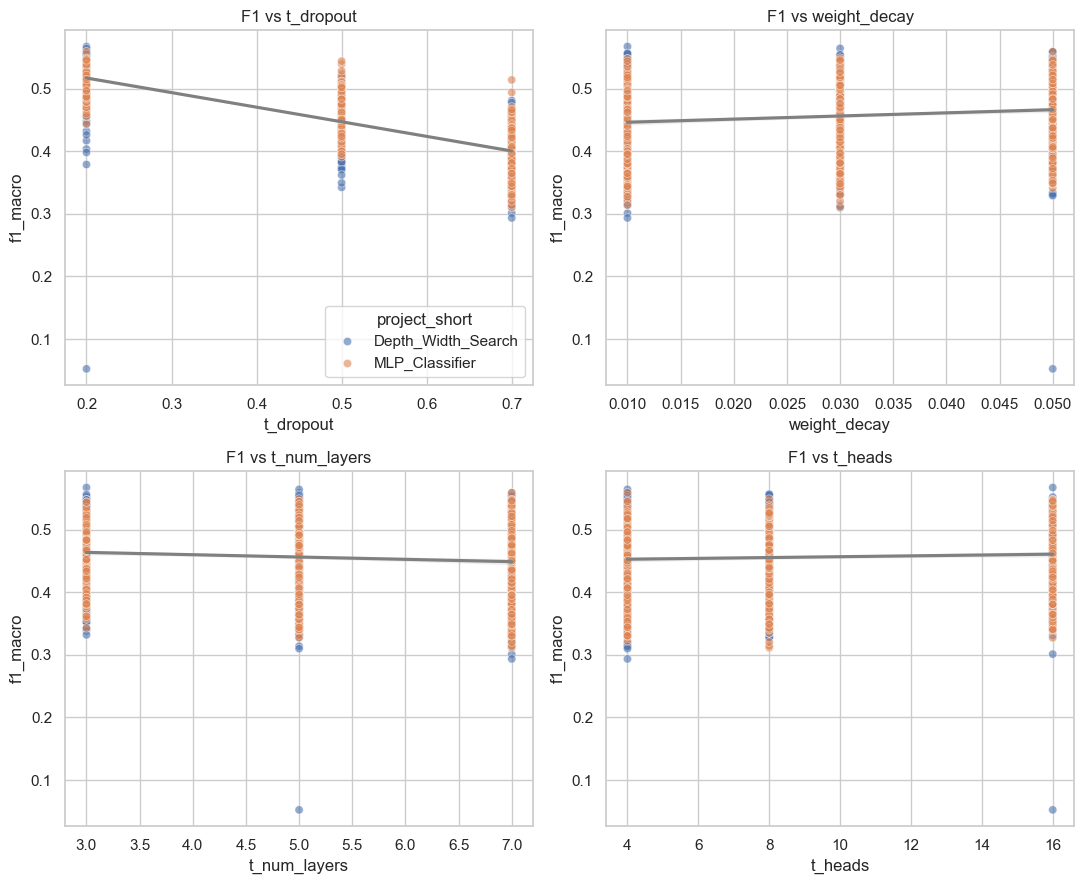

In [12]:
if len(df) == 0:
    print("Skip plots: empty dataframe")
else:
    sub = df.dropna(subset=["f1_macro"]).copy()
    num_cols = [
        "t_dropout",
        "weight_decay",
        "t_num_layers",
        "t_heads",
    ]
    present = [c for c in num_cols if c in sub.columns and sub[c].notna().any()]
    if present:
        corr = sub[["f1_macro"] + present].corr(numeric_only=True)["f1_macro"].drop("f1_macro")
        plt.figure(figsize=(8, max(3, len(corr) * 0.35)))
        corr.sort_values().plot(kind="barh", color="steelblue")
        plt.axvline(0, color="k", lw=0.5)
        plt.title("Pearson correlation: regularization / capacity vs F1 macro")
        plt.tight_layout()
        plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    axes = axes.ravel()
    for i, (ax, col) in enumerate(zip(axes, ["t_dropout", "weight_decay", "t_num_layers", "t_heads"])):
        if col not in sub.columns or sub[col].isna().all():
            ax.set_visible(False)
            continue
        sns.scatterplot(
            data=sub,
            x=col,
            y="f1_macro",
            hue="project_short",
            alpha=0.6,
            ax=ax,
            legend=(i == 0),
        )
        sns.regplot(data=sub, x=col, y="f1_macro", scatter=False, color="gray", ax=ax)
        ax.set_title(f"F1 vs {col}")
    plt.tight_layout()
    plt.show()

## 4. Data augmentation — do the probabilities matter?

Training uses `data/augmentation.py`: **jitter**, **shift**, **time warp**, **magnitude warp**, controlled by `jitter_prob`, `shift_prob`, `twarp_prob`, `mwarp_prob` (see `scripts/sweep_job.sh`).

The manuscript reports that augmentation **did not meaningfully change** performance. Here we check whether the sweep supports that: **Pearson r** (linear association with F1), **one-way η²** (share of variance between discrete levels of each prob), and **boxplots** by level. The grid is **confounded** (aug varies with other hyperparameters), so treat this as **supporting evidence**, not a causal ablation.

**Reading the numbers**: small |r| and small η² for aug vs **larger** η² for `patch_length` (reference) suggests augmentation is a weak lever relative to patching — consistent with “little impact.”

Pearson r (aug probability vs F1 macro):


,r
jitter_prob,NaN
shift_prob,NaN
twarp_prob,NaN
mwarp_prob,0.0199


,factor,eta_sq,eta_sq_patch_length,eta_sq_stride
0,jitter_prob,NaN,0.0079,0.0031
1,shift_prob,NaN,0.0079,0.0031
2,twarp_prob,NaN,0.0079,0.0031
3,mwarp_prob,0.0004,0.0079,0.0031


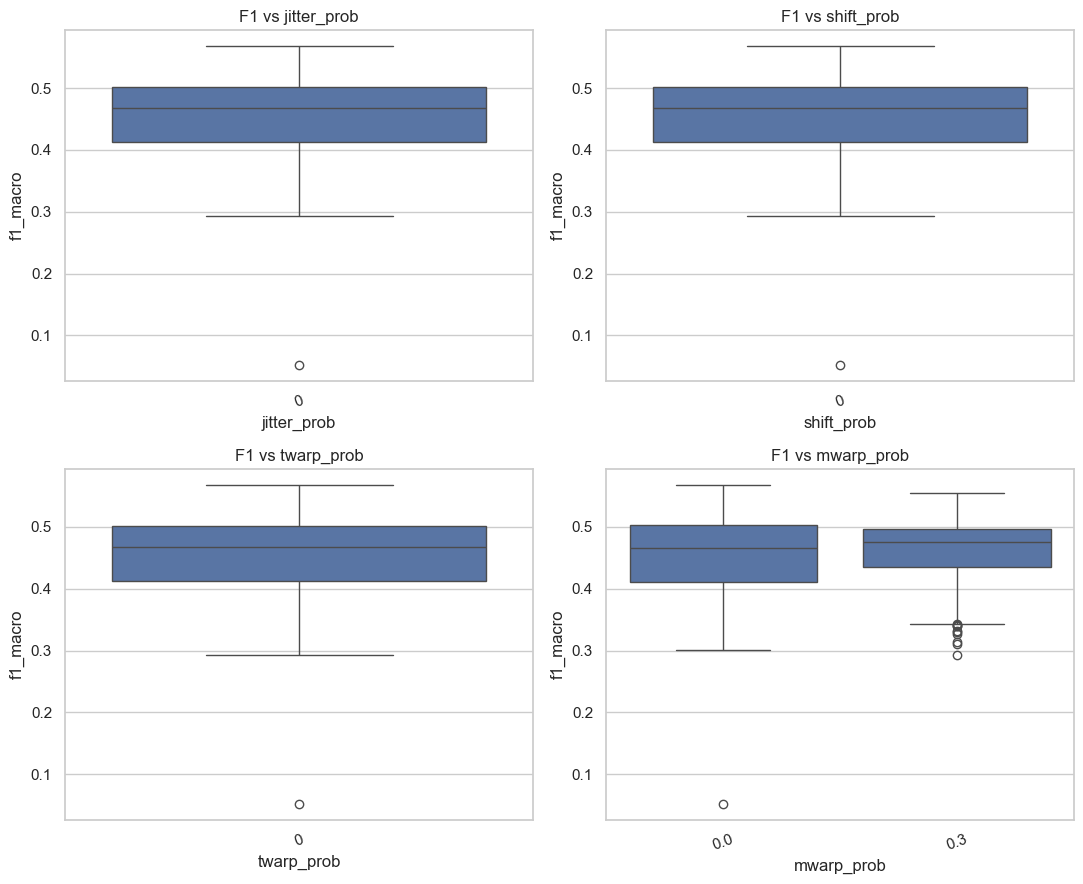

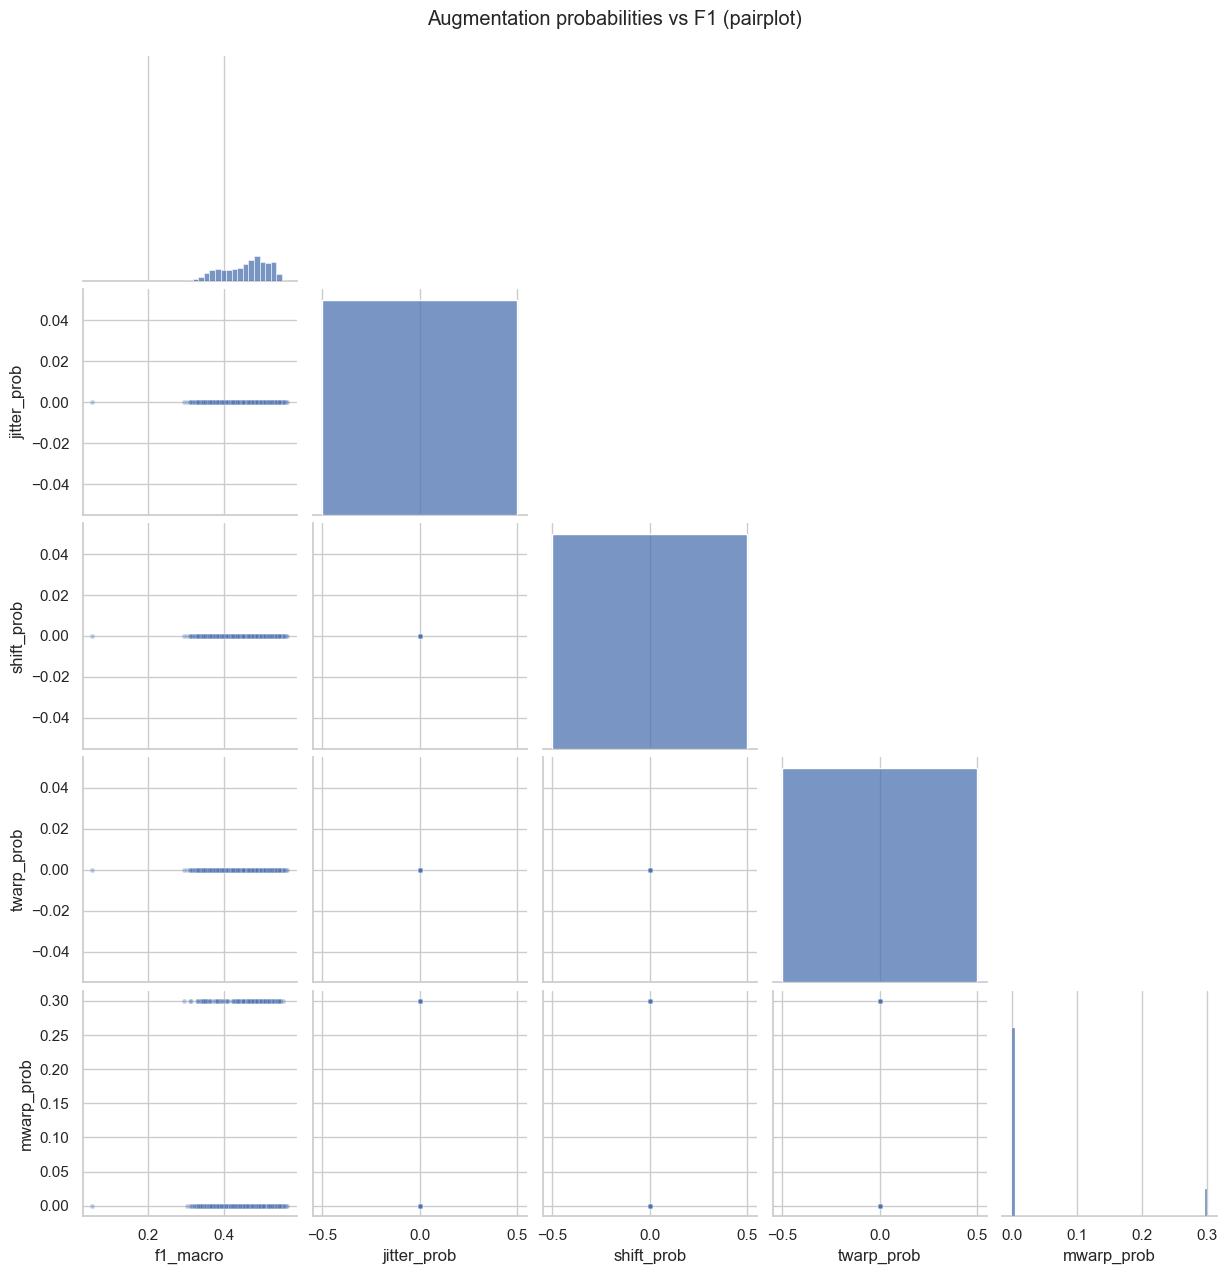


--- Heuristic summary (vs paper claim) ---
Max eta-squared among augmentation factors: 0.0004
Eta-squared for patch_length (reference): 0.0079
Eta-squared for stride (reference): 0.0031
Ratio max(eta_sq_aug) / eta_sq(patch_length) ~ 0.050 (values much smaller than 1 suggest aug explains less marginal variance than patch length).
Pattern: weak linear associations (|r|) and small eta-sq for aug vs patch — consistent with augmentation not moving F1 much (matches the paper’s observation).


In [6]:
def eta_squared_one_way(d: pd.DataFrame, factor: str, target: str = "f1_macro") -> float:
    """Between-group sum of squares / total SS (one-way ANOVA eta-squared)."""
    dd = d[[factor, target]].dropna()
    if dd[factor].nunique() < 2 or len(dd) < 3:
        return float("nan")
    grand_mean = dd[target].mean()
    ss_tot = ((dd[target] - grand_mean) ** 2).sum()
    if ss_tot <= 0:
        return float("nan")
    ss_between = 0.0
    for _, g in dd.groupby(factor):
        ss_between += len(g) * (g[target].mean() - grand_mean) ** 2
    return ss_between / ss_tot


if len(df) == 0:
    print("Skip augmentation analysis: empty dataframe")
else:
    sub = df.dropna(subset=["f1_macro"]).copy()
    aug_cols = [c for c in ["jitter_prob", "shift_prob", "twarp_prob", "mwarp_prob"] if c in sub.columns]

    if not aug_cols:
        print("No augmentation columns in dataframe.")
    else:
        r_aug = sub[aug_cols + ["f1_macro"]].corr(numeric_only=True)["f1_macro"].drop("f1_macro")
        print("Pearson r (aug probability vs F1 macro):")
        display(r_aug.round(4).to_frame("r"))

        rows = [{"factor": c, "eta_sq": eta_squared_one_way(sub, c)} for c in aug_cols]
        eta_aug = pd.DataFrame(rows)
        ref_patch = eta_squared_one_way(sub, "patch_length") if "patch_length" in sub.columns else float("nan")
        ref_stride = eta_squared_one_way(sub, "stride") if "stride" in sub.columns else float("nan")
        eta_aug["eta_sq_patch_length"] = ref_patch
        eta_aug["eta_sq_stride"] = ref_stride
        display(eta_aug.round(4))

        fig, axes = plt.subplots(2, 2, figsize=(11, 9))
        for ax, col in zip(axes.ravel(), aug_cols):
            sns.boxplot(data=sub, x=col, y="f1_macro", ax=ax)
            ax.set_title(f"F1 vs {col}")
            ax.tick_params(axis="x", rotation=20)
        plt.tight_layout()
        plt.show()

        aug_df = sub[["f1_macro"] + aug_cols].dropna()
        if len(aug_df) >= 5:
            try:
                                g = sns.pairplot(
                    aug_df,
                    corner=True,
                                        kind="kde",
                )
                g.fig.suptitle("Augmentation vs F1 (KDE; no scatter points)", y=1.02)
                plt.show()
            except Exception as e:
                print("pairplot skipped:", e)

        mx = eta_aug["eta_sq"].max()
        print("\n--- Heuristic summary (vs paper claim) ---")
        if pd.notna(mx):
            print(f"Max eta-squared among augmentation factors: {mx:.4f}")
        if pd.notna(ref_patch):
            print(f"Eta-squared for patch_length (reference): {ref_patch:.4f}")
        if pd.notna(ref_stride):
            print(f"Eta-squared for stride (reference): {ref_stride:.4f}")
        if pd.notna(mx) and pd.notna(ref_patch) and ref_patch > 0:
            print(
                f"Ratio max(eta_sq_aug) / eta_sq(patch_length) ~ {mx / ref_patch:.3f} "
                "(values much smaller than 1 suggest aug explains less marginal variance than patch length)."
            )
        ratio = mx / ref_patch if pd.notna(mx) and pd.notna(ref_patch) and ref_patch > 0 else float("nan")
        weak_r = r_aug.abs().max() < 0.1
        weak_eta = pd.isna(mx) or mx < 0.05 or (pd.notna(ratio) and ratio < 0.2)
        if weak_r and weak_eta:
            print(
                "Pattern: weak linear associations (|r|) and small eta-sq for aug vs patch — "
                "consistent with augmentation not moving F1 much (matches the paper’s observation)."
            )
        else:
            print(
                "Pattern: possible non-negligible aug effects in this table — the grid is confounded; "
                "compare effect sizes to patch/stride and prefer controlled ablations to confirm."
            )

## 5. Export top 10 configs (YAML)

Writes `configs/grid_top_1.yaml` … `configs/grid_top_10.yaml` from `configs/config_1.yaml` plus each run’s hyperparameters. Set `run_name` / `output_dir` for your next phase.

In [7]:
TOP_K = 10

if len(df) == 0 or df["f1_macro"].isna().all():
    print("No data to export.")
else:
    ranked = df.sort_values("f1_macro", ascending=False).head(TOP_K).reset_index(drop=True)
    display(ranked[
        [
            "f1_macro",
            "project",
            "name",
            "patch_length",
            "stride",
            "classifier",
            "t_dropout",
            "weight_decay",
            "t_num_layers",
            "t_heads",
        ]
    ])

    if not BASE_CONFIG_PATH.is_file():
        print(f"Missing base config: {BASE_CONFIG_PATH}")
    else:
        CONFIG_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        for i, row in ranked.iterrows():
            rank = i + 1
            cfg = merge_config_with_base(row, BASE_CONFIG_PATH)
            cfg["run_name"] = f"grid_top_{rank}_phase2"
            cfg["output_dir"] = f"grid_top_{rank}/"
            out_path = CONFIG_EXPORT_DIR / f"grid_top_{rank}.yaml"
            with open(out_path, "w") as f:
                f.write(f"# Top {rank}/{TOP_K} by best macro F1 = {row['f1_macro']:.6f}\n")
                f.write(f"# source run: {row['project']} / {row['name']} ({row['run_id']})\n")
                yaml.safe_dump(cfg, f, default_flow_style=False, sort_keys=False)
            print("Wrote", out_path)
        print("Done.")

,f1_macro,project,name,patch_length,stride,classifier,t_dropout,weight_decay,t_num_layers,t_heads
0,0.567412,PatchTST_Depth_Width_Search,pl64_s16_lr0.001_do0.2_L3_optadamw_h16_wd0p01_...,64,16,linear,0.2,0.01,3,16
1,0.564465,PatchTST_Depth_Width_Search,pl64_s32_lr0.001_do0.2_L5_optadamw_h4_wd0p03_c...,64,32,linear,0.2,0.03,5,4
2,0.559120,PatchTST_MLP_Classifier,pl128_s8_lr0.001_do0.2_L7_optadamw_h4_wd0p05_c...,128,8,mlp,0.2,0.05,7,4
3,0.558876,PatchTST_Depth_Width_Search,pl64_s16_lr0.001_do0.2_L7_optadamw_h4_wd0p05_c...,64,16,linear,0.2,0.05,7,4
4,0.558795,PatchTST_Depth_Width_Search,pl64_s8_lr0.001_do0.2_L5_optadamw_h4_wd0p05_cl...,64,8,linear,0.2,0.05,5,4
5,0.558745,PatchTST_Depth_Width_Search,pl32_s8_lr0.001_do0.2_L5_optadamw_h4_wd0p05_cl...,32,8,linear,0.2,0.05,5,4
6,0.556700,PatchTST_Depth_Width_Search,pl128_s16_lr0.001_do0.2_L5_optadamw_h8_wd0p01_...,128,16,linear,0.2,0.01,5,8
7,0.556242,PatchTST_Depth_Width_Search,pl64_s32_lr0.001_do0.2_L3_optadamw_h8_wd0p01_c...,64,32,linear,0.2,0.01,3,8
8,0.555055,PatchTST_Depth_Width_Search,pl64_s32_lr0.001_do0.2_L7_optadamw_h8_wd0p01_c...,64,32,linear,0.2,0.01,7,8
9,0.554605,PatchTST_Depth_Width_Search,pl32_s16_lr0.001_do0.2_L5_optadamw_h4_wd0p03_c...,32,16,linear,0.2,0.03,5,4


Wrote /Users/nikhiltrivedi/Desktop/CS_ML/Transformer_HAC/configs/grid_top_1.yaml
Wrote /Users/nikhiltrivedi/Desktop/CS_ML/Transformer_HAC/configs/grid_top_2.yaml
Wrote /Users/nikhiltrivedi/Desktop/CS_ML/Transformer_HAC/configs/grid_top_3.yaml
Wrote /Users/nikhiltrivedi/Desktop/CS_ML/Transformer_HAC/configs/grid_top_4.yaml
Wrote /Users/nikhiltrivedi/Desktop/CS_ML/Transformer_HAC/configs/grid_top_5.yaml
Wrote /Users/nikhiltrivedi/Desktop/CS_ML/Transformer_HAC/configs/grid_top_6.yaml
Wrote /Users/nikhiltrivedi/Desktop/CS_ML/Transformer_HAC/configs/grid_top_7.yaml
Wrote /Users/nikhiltrivedi/Desktop/CS_ML/Transformer_HAC/configs/grid_top_8.yaml
Wrote /Users/nikhiltrivedi/Desktop/CS_ML/Transformer_HAC/configs/grid_top_9.yaml
Wrote /Users/nikhiltrivedi/Desktop/CS_ML/Transformer_HAC/configs/grid_top_10.yaml
Done.
